In [1]:
import numpy as numpy
import pandas as pd

In [2]:
df = pd.read_csv('spam.csv', encoding="latin-1")


In [3]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
5434,ham,Jesus armand really is trying to tell everybod...,NaN,NaN,NaN
5059,ham,I think i am disturbing her da,NaN,NaN,NaN
339,ham,U calling me right? Call my hand phone...,NaN,NaN,NaN
997,ham,Not a lot has happened here. Feels very quiet....,NaN,NaN,NaN
1916,ham,Fffff. Can you text kadeem or are you too far ...,NaN,NaN,NaN


steps 
1- Data Cleaning
2- EDA
3 - Text processing
4 - Model building
5 - Evaluation
6 - Improvement
7 - Website
8 - Deploy

# Data Cleaning

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 217.8 KB


In [5]:
# drop Last 3 columns
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True)

In [6]:
df.sample(5)

,v1,v2
4030,ham,"Sorry vikky, i'm Watching olave mandara movie ..."
3220,spam,"Thanks for your ringtone order, reference numb..."
3380,spam,"complimentary 4 STAR Ibiza Holiday or å£10,000..."
4713,ham,Oops i thk i dun haf enuff... I go check then ...
5282,ham,I have gone into get info bt dont know what to do


In [7]:

# rename the columns
df.rename(columns={'v1':'ID','v2':'TEXT'}, inplace=True)
df.sample(5)

,ID,TEXT
1471,ham,Oh. U must have taken your REAL Valentine out ...
319,ham,"Coffee cake, i guess..."
1202,ham,"Me also da, i feel yesterday night wait til 2..."
991,ham,Hi im having the most relaxing time ever! we h...
3172,spam,"Dear Voucher Holder, To claim this weeks offer..."


In [8]:
import sys
print(sys.executable)

/usr/local/bin/python3


In [9]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df['ID']=encoder.fit_transform(df['ID'])


In [10]:
df.head()

,ID,TEXT
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [11]:
#missing values
df.isnull().sum()

ID      0
TEXT    0
dtype: int64

In [12]:
# check for the duplicate values
df.duplicated().sum()

np.int64(403)

In [13]:
# remove duplicates
df = df.drop_duplicates(keep='first')

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df.shape

(5169, 2)

# 2 EDA

In [16]:
df.head()

,ID,TEXT
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [17]:
df['ID'].value_counts()

ID
0    4516
1     653
Name: count, dtype: int64

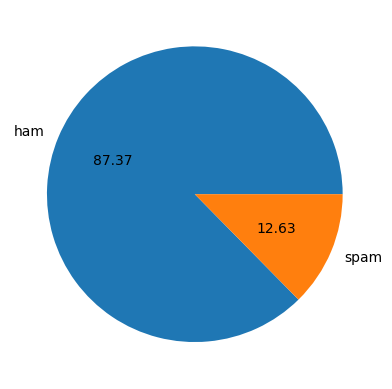

In [18]:
import matplotlib.pyplot as plt
plt.pie(df['ID'].value_counts(), labels=['ham','spam'], autopct="%0.2f")
plt.show()

In [19]:
import nltk

print(nltk.data.path)

['/Users/krishna/nltk_data', '/Library/Frameworks/Python.framework/Versions/3.14/nltk_data', '/Library/Frameworks/Python.framework/Versions/3.14/share/nltk_data', '/Library/Frameworks/Python.framework/Versions/3.14/lib/nltk_data', '/usr/share/nltk_data', '/usr/local/share/nltk_data', '/usr/lib/nltk_data', '/usr/local/lib/nltk_data']


In [20]:
df['num_characters']=df['TEXT'].apply(len)


In [21]:
df.head()

,ID,TEXT,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [22]:
df['num_words']=df['TEXT'].apply(lambda x:len(nltk.word_tokenize(x))) # braeking the message word by words

In [23]:
df.head()

,ID,TEXT,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [24]:
df['num_sentences']=df['TEXT'].apply(lambda x:len(nltk.sent_tokenize(x))) # braeking the message sentence by sen
                                                                         # len() giving the number of the sentences
df.head()                                                                         

,ID,TEXT,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [25]:
df[['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.460437,1.965564
std,58.236293,13.334441,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [26]:
# Ham 
df[df['ID'] == 0][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.128432,1.820195
std,56.358207,13.504730,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [27]:
# Spam
df[df['ID'] == 1][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.672282,2.970904
std,30.137753,7.010932,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [28]:
# histogram
import seaborn as sns


<Axes: xlabel='num_characters', ylabel='Count'>

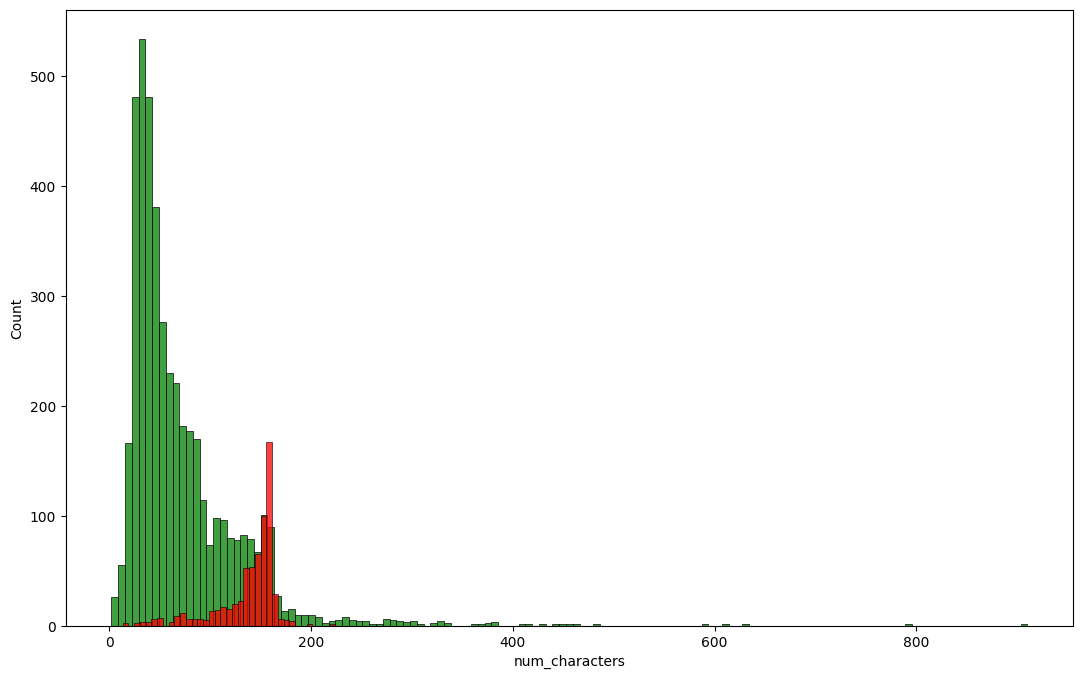

In [29]:
plt.figure(figsize=(13,8))
sns.histplot(df[df['ID'] == 0]['num_characters'],color='green')
sns.histplot(df[df['ID'] == 1]['num_characters'],color='red')


<Axes: xlabel='num_words', ylabel='Count'>

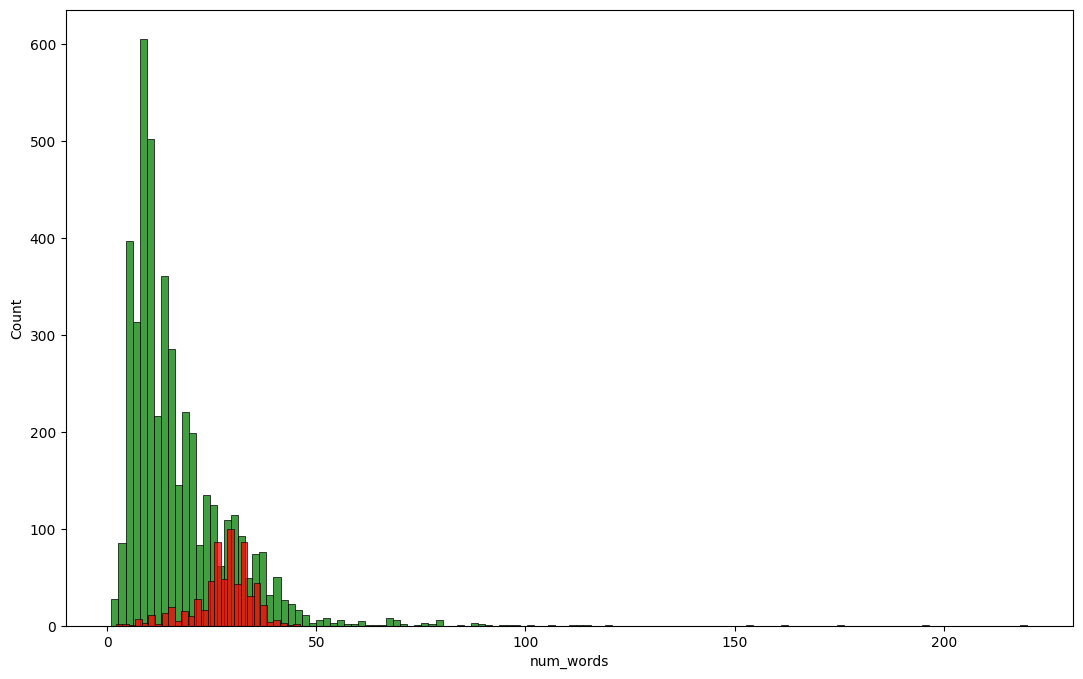

In [30]:
plt.figure(figsize=(13,8))
sns.histplot(df[df['ID'] == 0]['num_words'],color='green')
sns.histplot(df[df['ID'] == 1]['num_words'],color='red')


<Axes: xlabel='num_sentences', ylabel='Count'>

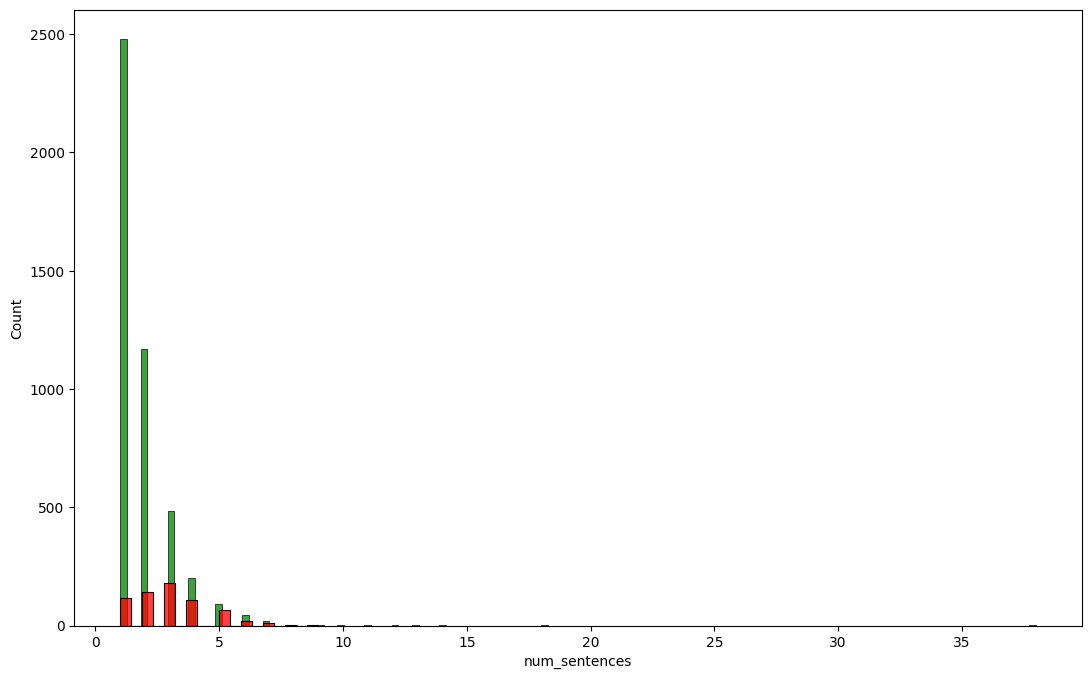

In [ ]:
plt.figure(figsize=(13,8))

sns.histplot(df[df['ID'] == 0]['num_sentences'],color='green')
sns.histplot(df[df['ID'] == 1]['num_sentences'],color='red')


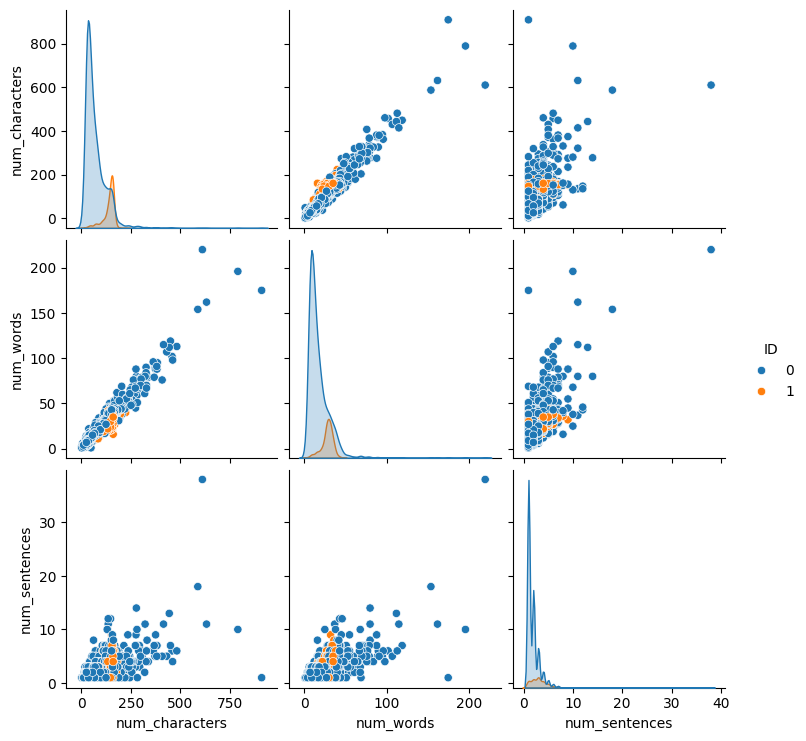

In [32]:
sns.pairplot(df,hue="ID")


<Axes: >

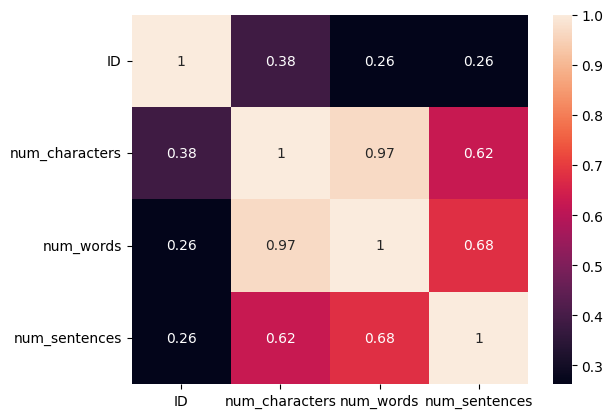

In [33]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

# 3. Data Preprocessing

In [34]:
import nltk
import string

from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

ps = PorterStemmer()
def transform_text(text):
    text = text.lower() # transform the each words into lower case
    text = nltk.word_tokenize(text) # word tokenization
    # checking for the alphanumeric
    y =[]
    for i in text:
        if i.isalnum(): #removing the special characters
            
            y.append(i)
            
    text = y[:] #clonning
    y.clear()
    
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)      
    text = y[:]
    y.clear()
    
    for i in text:
        y.append(ps.stem(i))
   
    return " ".join(y)

In [35]:
transform_text("I\'m gonna be home soon and i don\'t want to talk about this stuff anymore tonight, k? I'\ve cried enough today.")


'gon na home soon want talk stuff anymor tonight k e cri enough today'

In [36]:
df['TEXT'][10]


"I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today."

In [37]:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
ps.stem('Coding')

'code'

In [38]:
df['transformed_text']=df["TEXT"].apply(transform_text)

In [39]:
df.head()

,ID,TEXT,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


# wordcloud

In [40]:
from wordcloud import WordCloud
wc = WordCloud(width=500,height=500, min_font_size=10, background_color = 'white')

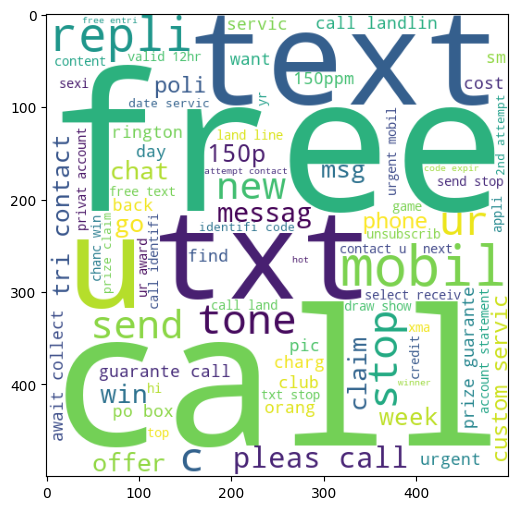

In [41]:
spam_wc=wc.generate(df[df['ID'] == 1]['transformed_text'].str.cat(sep = " "))
plt.figure(figsize=(12,6))

plt.imshow(spam_wc)

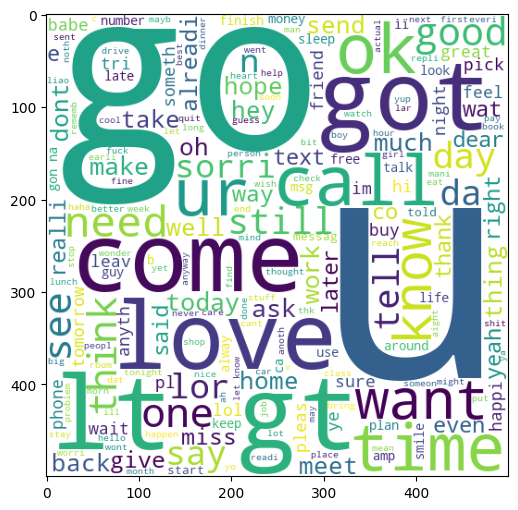

In [42]:
ham_wc=wc.generate(df[df['ID'] == 0]['transformed_text'].str.cat(sep = " "))
plt.figure(figsize=(12,6))

plt.imshow(ham_wc)

In [43]:
df.head()

,ID,TEXT,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [44]:
spam_corpus = []
for msg in df[df['ID'] == 1]['transformed_text'].tolist():
    for words in msg.split():
        spam_corpus.append(words)

In [45]:
len(spam_corpus)

9942

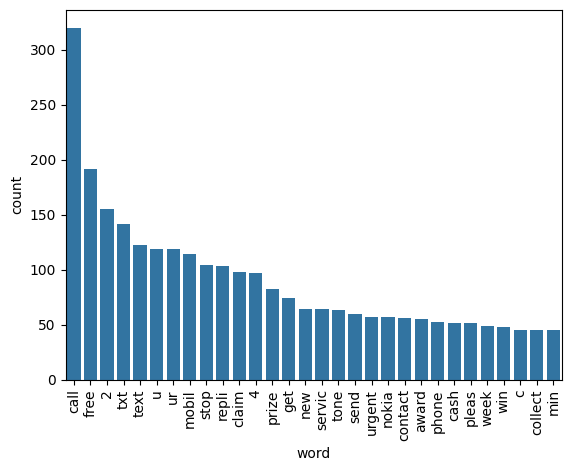

In [46]:
'''recognizing the top spam words'''

from collections import Counter
data = pd.DataFrame(Counter(spam_corpus).most_common(30),columns=['word','count'])
sns.barplot(x='word', y = 'count', data=data)

plt.xticks(rotation ='vertical')
plt.show()

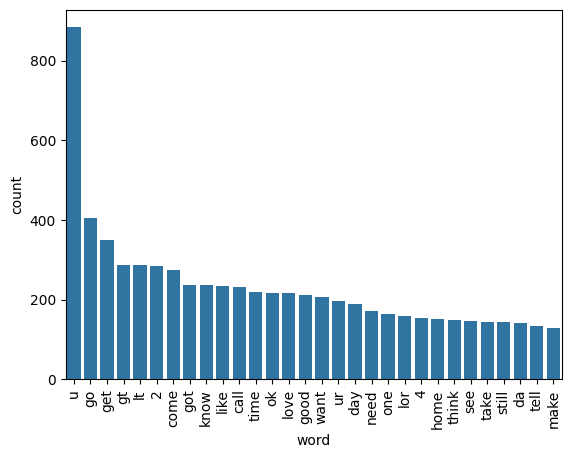

In [47]:
'''recognizing the top ham words'''

ham_corpus = []
for msg in df[df['ID'] == 0]['transformed_text'].tolist():
    for words in msg.split():
        ham_corpus.append(words)
len(ham_corpus)



from collections import Counter
data = pd.DataFrame(Counter(ham_corpus).most_common(30),columns=['word','count'])
sns.barplot(x='word', y = 'count', data=data)

plt.xticks(rotation ='vertical')
plt.show()


In [48]:
df.head()

,ID,TEXT,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


# 4 Model Buuilding

In [49]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
cv = CountVectorizer()
tfidf = TfidfVectorizer()

X = tfidf.fit_transform(df['transformed_text']).toarray()
X.shape

(5169, 6715)

In [50]:
y = df['ID'].values
y

array([0, 0, 1, ..., 0, 0, 0], shape=(5169,))

In [51]:
from sklearn.model_selection import train_test_split

In [52]:
X_train,X_test,y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [53]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [54]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [55]:
gnb.fit(X_train,y_train)
y_pred1 = gnb.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test, y_pred1))

0.8762088974854932
[[793 103]
 [ 25 113]]
0.5231481481481481


In [56]:
mnb.fit(X_train,y_train)
y_pred2 = mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test, y_pred2))

0.9593810444874274
[[896   0]
 [ 42  96]]
1.0


In [57]:
bnb.fit(X_train,y_train)
y_pred3 = bnb.predict(X_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test, y_pred3))

0.9700193423597679
[[893   3]
 [ 28 110]]
0.9734513274336283


#Selected tfidf and mnb 

In [58]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
